In [1]:
# Load Libraries

# data manipulation 
import pandas as pd
import numpy as np

# plotting
import seaborn as sns
import matplotlib.pyplot as plt

# neuron visualizations
from brainrender import Scene
from brainrender.actors import Points

import vedo
vedo.settings.default_backend= 'vtk'

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster import hierarchy

In [2]:
#want to do clustering on snr using the features the describe the projection type of the neurons,
#then we want to see if those clusters are reflected by the "proj" labels.

# load data
ec_snr_data = pd.read_csv("master_detailed_comment.csv")

ec_snr_data.head()


,mouseID,neuronNR,neuron_ID,FRP_endpoint,FRP_length,SS_endpoint,SS_length,VIS_endpoint,VIS_length,VISpor_endpoint,...,STRd_length,STRv_endpoint,STRv_length,x,y,z,comment,injection,proj,count
0,1056,2,1056_2,0,52.590655,0,0.00000,4,2850.742552,9,...,35586.500280,79,70750.246650,9662.4,3506.8,9755.3,NaN,ORB,rsp_orb,6
1,1056,41,1056_41,0,0.000000,0,0.00000,7,3031.117311,1,...,8835.140534,7,10849.726100,9791.9,3825.0,9756.8,NaN,ORB,rsp_orb,5
2,1056,6,1056_6,0,133.352838,15,15402.66771,11,12446.070610,1,...,57612.283980,71,69422.052800,9680.9,3897.0,9768.1,NaN,ORB,rsp_orb,8
3,1056,26,1056_26,0,0.000000,1,140.00601,11,9656.228320,17,...,30481.705940,16,7439.897194,9844.7,3033.5,9482.4,NA injection area has 0 endpoints injection ar...,ORB,NaN,6
4,1056,31,1056_31,0,148.433770,0,0.00000,0,0.000000,0,...,26718.999420,81,75650.137140,9232.8,4481.3,10019.4,NaN,ORB,orb,3


In [3]:
ec_snr_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237 entries, 0 to 236
Data columns (total 68 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   mouseID          237 non-null    int64  
 1   neuronNR         237 non-null    int64  
 2   neuron_ID        237 non-null    object 
 3   FRP_endpoint     237 non-null    int64  
 4   FRP_length       237 non-null    float64
 5   SS_endpoint      237 non-null    int64  
 6   SS_length        237 non-null    float64
 7   VIS_endpoint     237 non-null    int64  
 8   VIS_length       237 non-null    float64
 9   VISpor_endpoint  237 non-null    int64  
 10  VISpor_length    237 non-null    float64
 11  RSP_endpoint     237 non-null    int64  
 12  RSP_length       237 non-null    float64
 13  PTLp_endpoint    237 non-null    int64  
 14  PTLp_length      237 non-null    float64
 15  ORB_endpoint     237 non-null    int64  
 16  ORB_length       237 non-null    float64
 17  MO_endpoint     

EDA


In [4]:
# To make this notebook's output identical at every run
rng = np.random.seed(0)

#Define the database that will be cleaned and preprocessed
df = ec_snr_data.copy()

#Keep in the database only the variables that explain connectivity patterns 
cols_to_drop = ["mouseID", "neuronNR", "neuron_ID", "x", "y", "z", "comment", "injection", "proj", "count"]

labels = df["proj"]
df = df.drop(columns=cols_to_drop)

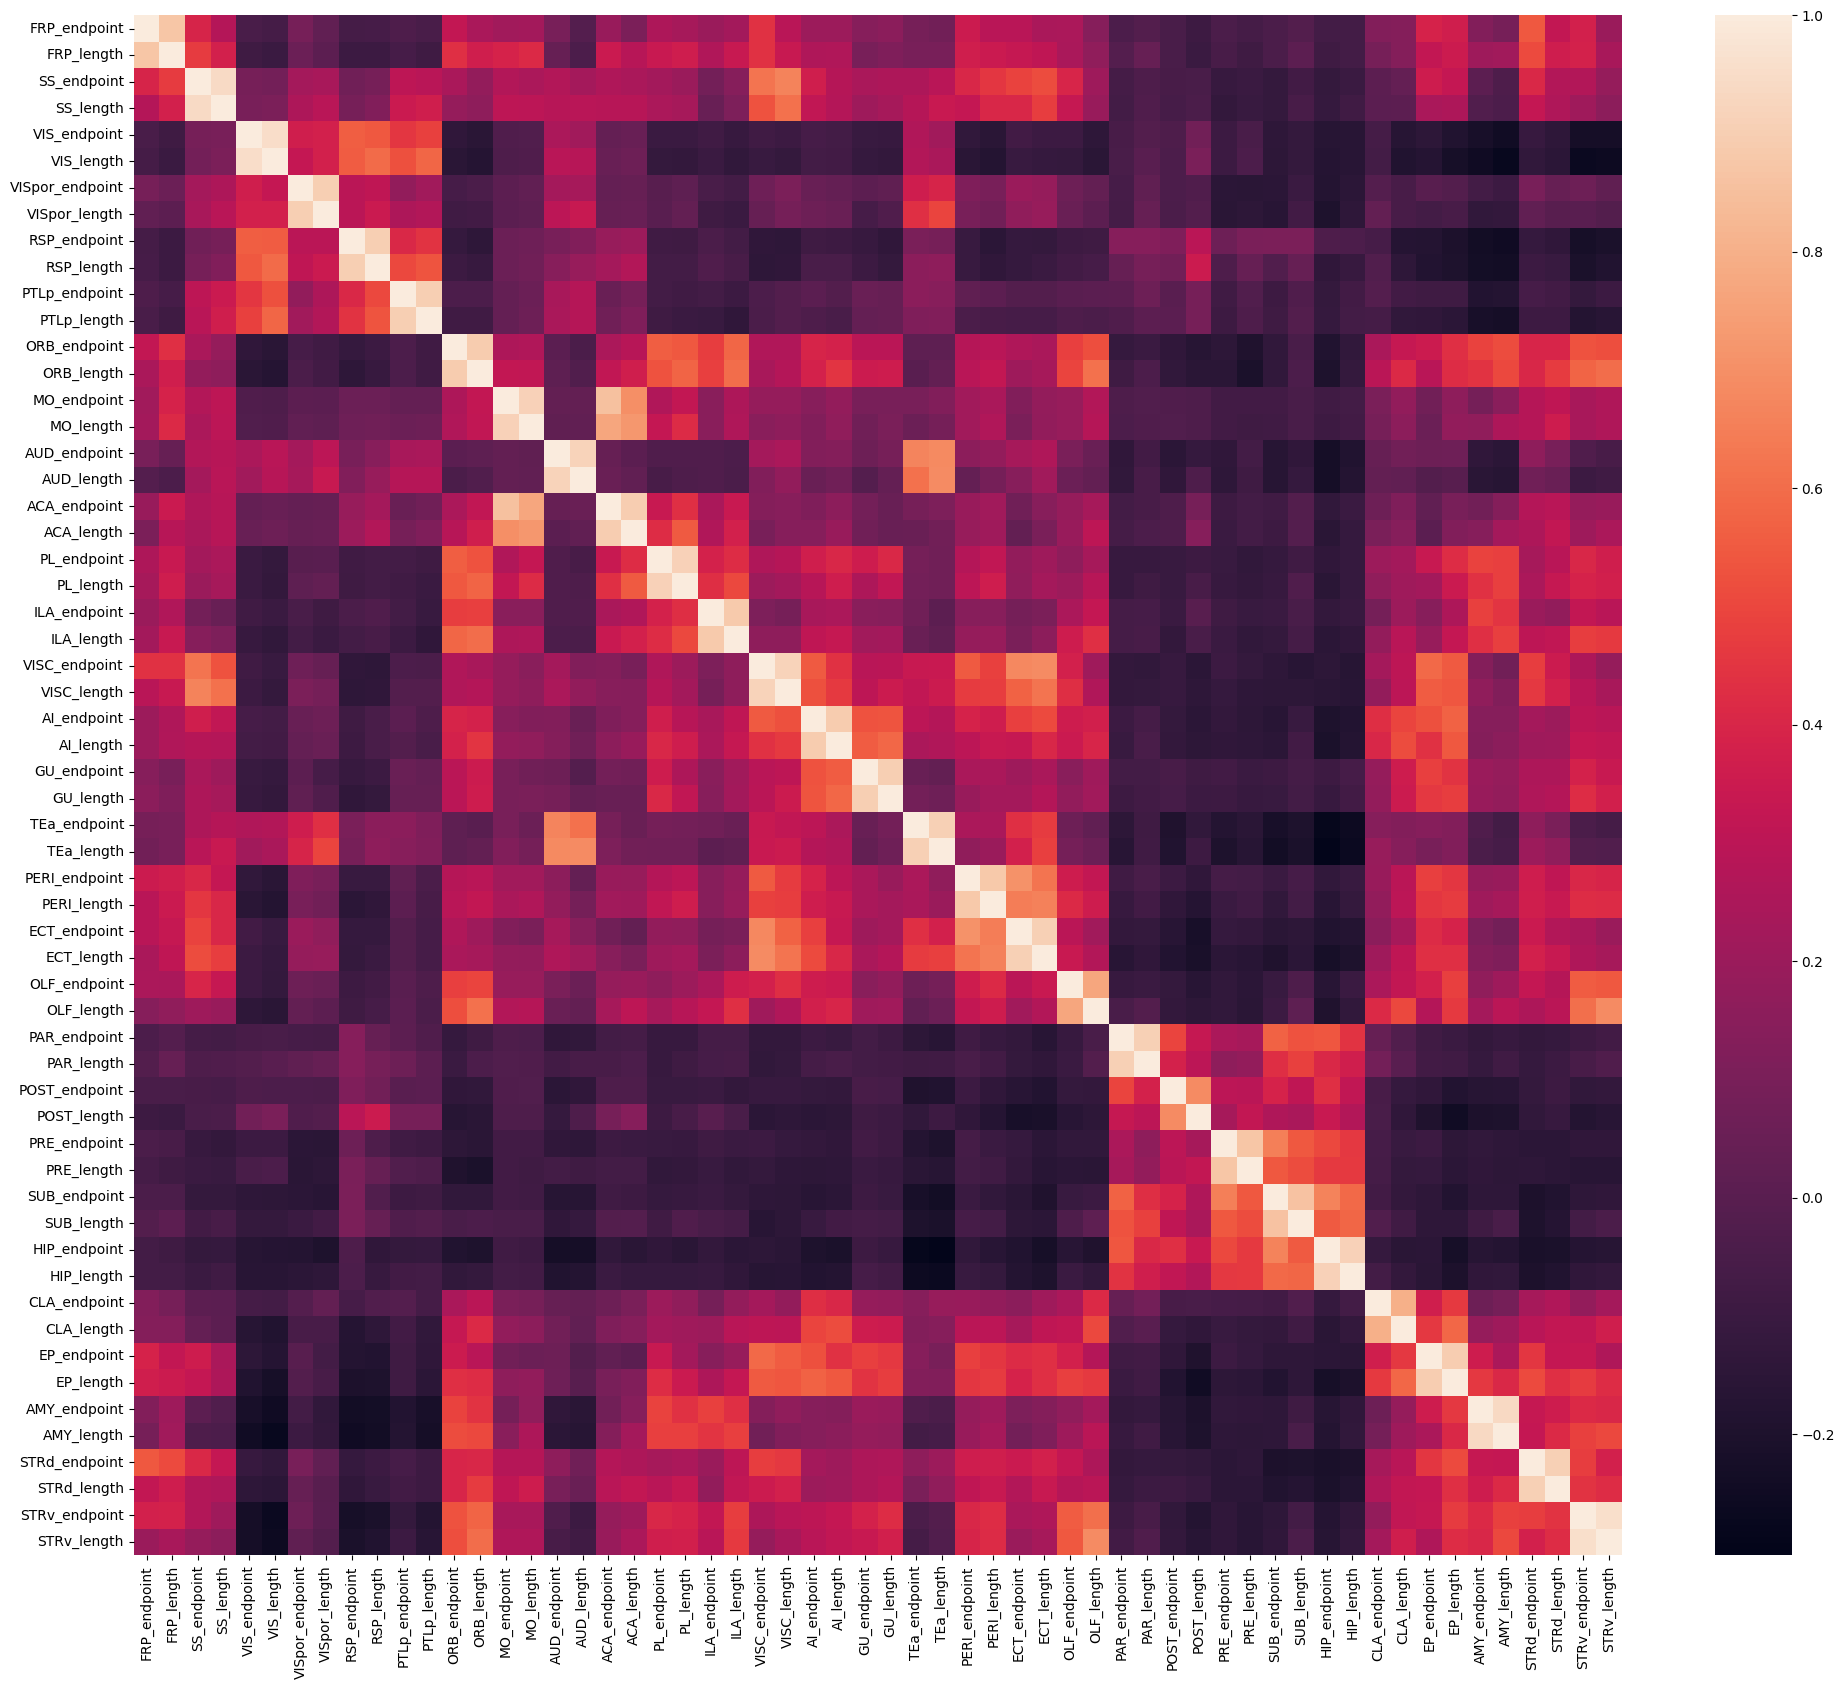

In [5]:
plt.figure(figsize=(24, 20))
sns.heatmap(df.corr())
plt.show()

Length and endpoint appear to be highly correlated, we can remove either one from each of the encoded regions. Moreover, we clearly see some structure in the correlation patterns. We can use PCA before clustering to capture to move to a lower dimensional space and then apply PCA on the lower dimensional space.

In [6]:
#Get the columns that end with "_endpoint"
endpoint_cols = []

for col in df.columns:
    if col.endswith("_endpoint"):
        endpoint_cols.append(col)

In [7]:
#Remove endpoint columns from the dataframe
df = df.drop(columns=endpoint_cols)

In [8]:
#df.head()
# for col in df.columns:
#     sns.histplot(data=df, x=col)
#     plt.tight_layout()
#     plt.show()

In [9]:
#df = np.log1p(df)

#df.head()
#for col in df.columns:
    #sns.histplot(data=df, x=col)
    #plt.tight_layout()
    #plt.show()

In [10]:
#Scale the data

scaler = StandardScaler()
df_transitory = scaler.fit_transform(df)

df = pd.DataFrame(
    df_transitory,
    columns = df.columns,
    index = df.index
)

PCA

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA


In [12]:
pca = PCA()
pca.fit(df)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

(0.0, 100.0)

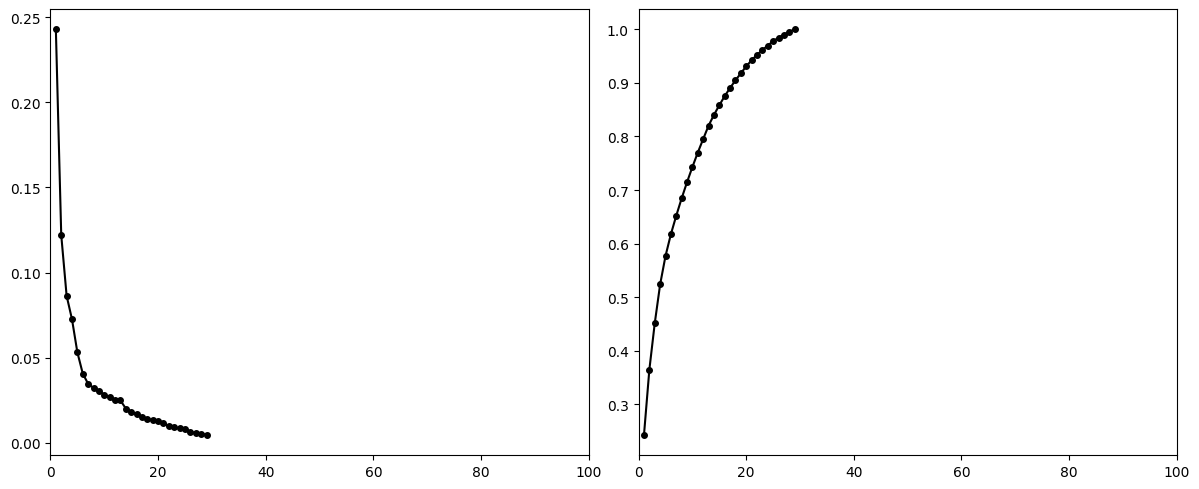

In [13]:
#selecting number of components
explained_var = pca.explained_variance_
explained_var_ratio = pca.explained_variance_ratio_
x = np.linspace(1,len(explained_var),len(explained_var))
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,5))
ax[0].plot(x, explained_var_ratio[0:200], 'k-', marker = 'o', markersize=4)
ax[1].plot(x,explained_var_ratio.cumsum()[0:200], 'k-', marker = 'o', markersize=4)
fig.tight_layout()
ax[0].set_xlim(0,100)
ax[1].set_xlim(0,100)

the first 18 components explain more ore less 90% of variability

In [14]:
#Let's get the new feature matrix
pca2 = PCA(n_components = 18)
low_dim_df_trans = pca2.fit_transform(df)

In [15]:
low_dim_df = pd.DataFrame(
    low_dim_df_trans,
    columns = [f"PCA{i+1}" for i in range(low_dim_df_trans.shape[1])]
)

In [16]:
low_dim_df.head()
low_dim_df_array = np.asarray(low_dim_df)


Run clustering algorithm on the new dataframe - try hierarchical clustering first with different types of linkage

In [17]:
#get labels which will be used for plotting later

labels.value_counts() 
labels.head()
#Replace NAs with something else
labels = labels.fillna("NA")

In [18]:
print(f"Shape of labels pd serie {labels.shape}")
print(f"Shape of feature matrix {low_dim_df.shape}")

Shape of labels pd serie (237,)
Shape of feature matrix (237, 18)


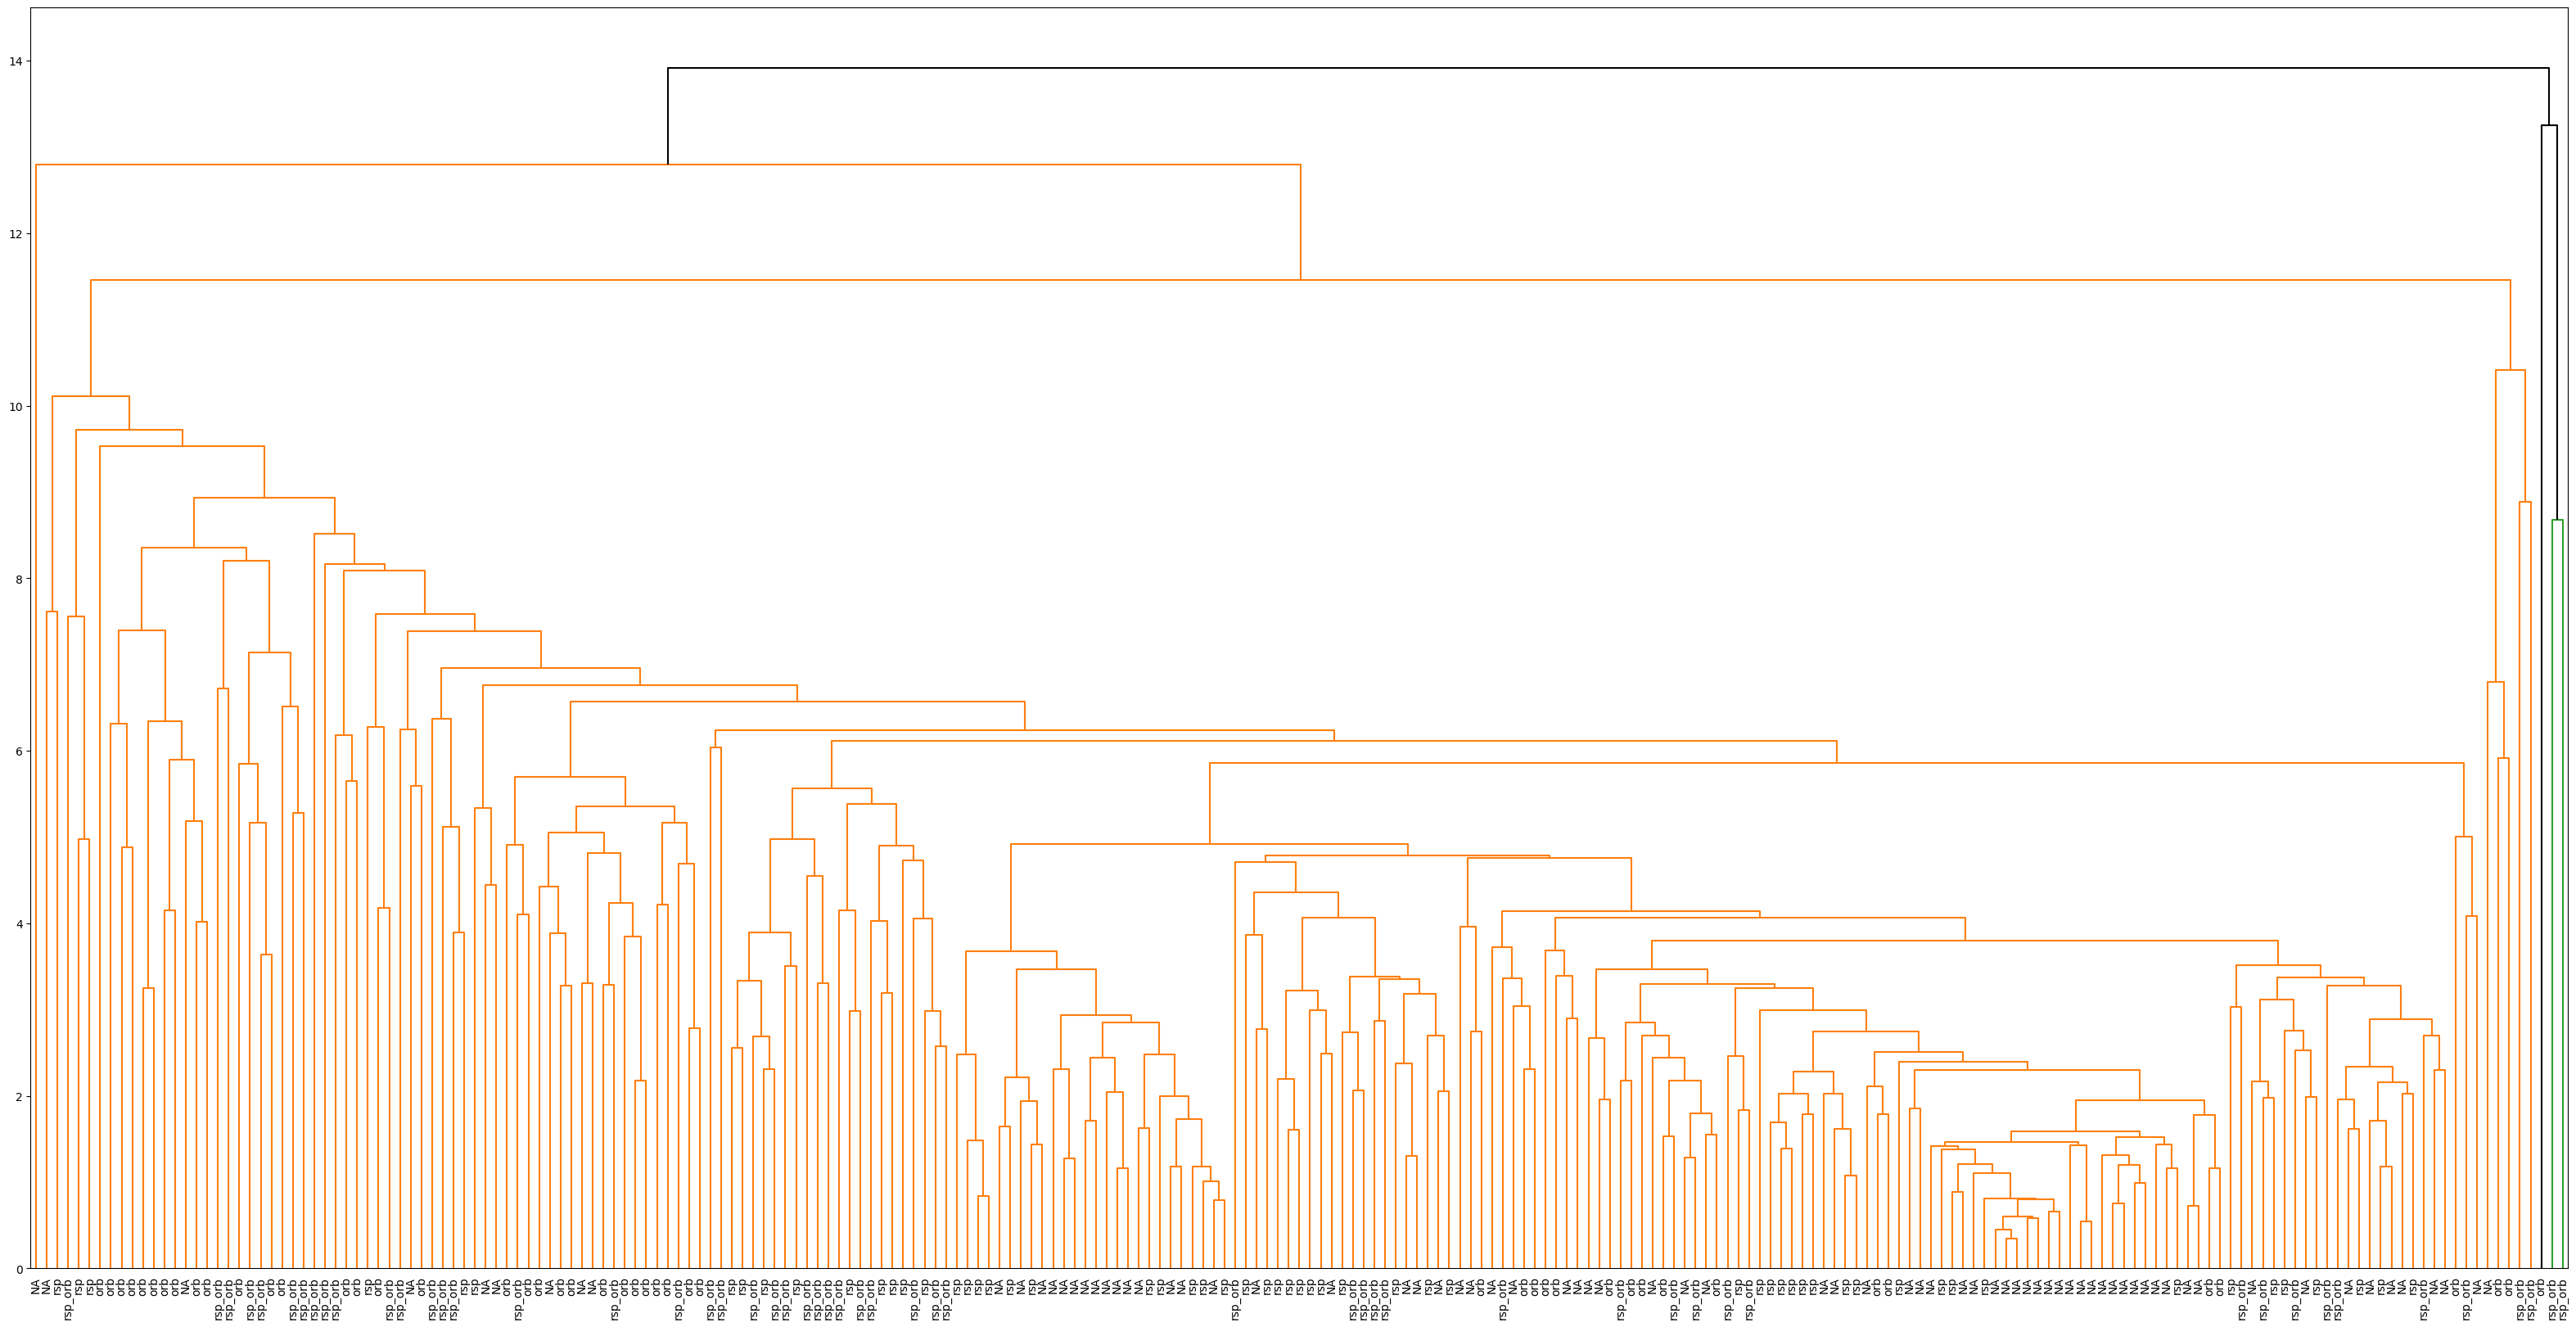

In [19]:
#Run hierarchical clustering
hc_avg = hierarchy.linkage(low_dim_df_array, method='average')
# Plot the dendrogram
fig, ax = plt.subplots(1, 1, figsize=(40,20))
hierarchy.dendrogram(hc_avg, ax=ax, labels=np.asarray(labels),
                     color_threshold=13, above_threshold_color='black', leaf_font_size = 10)
plt.show()


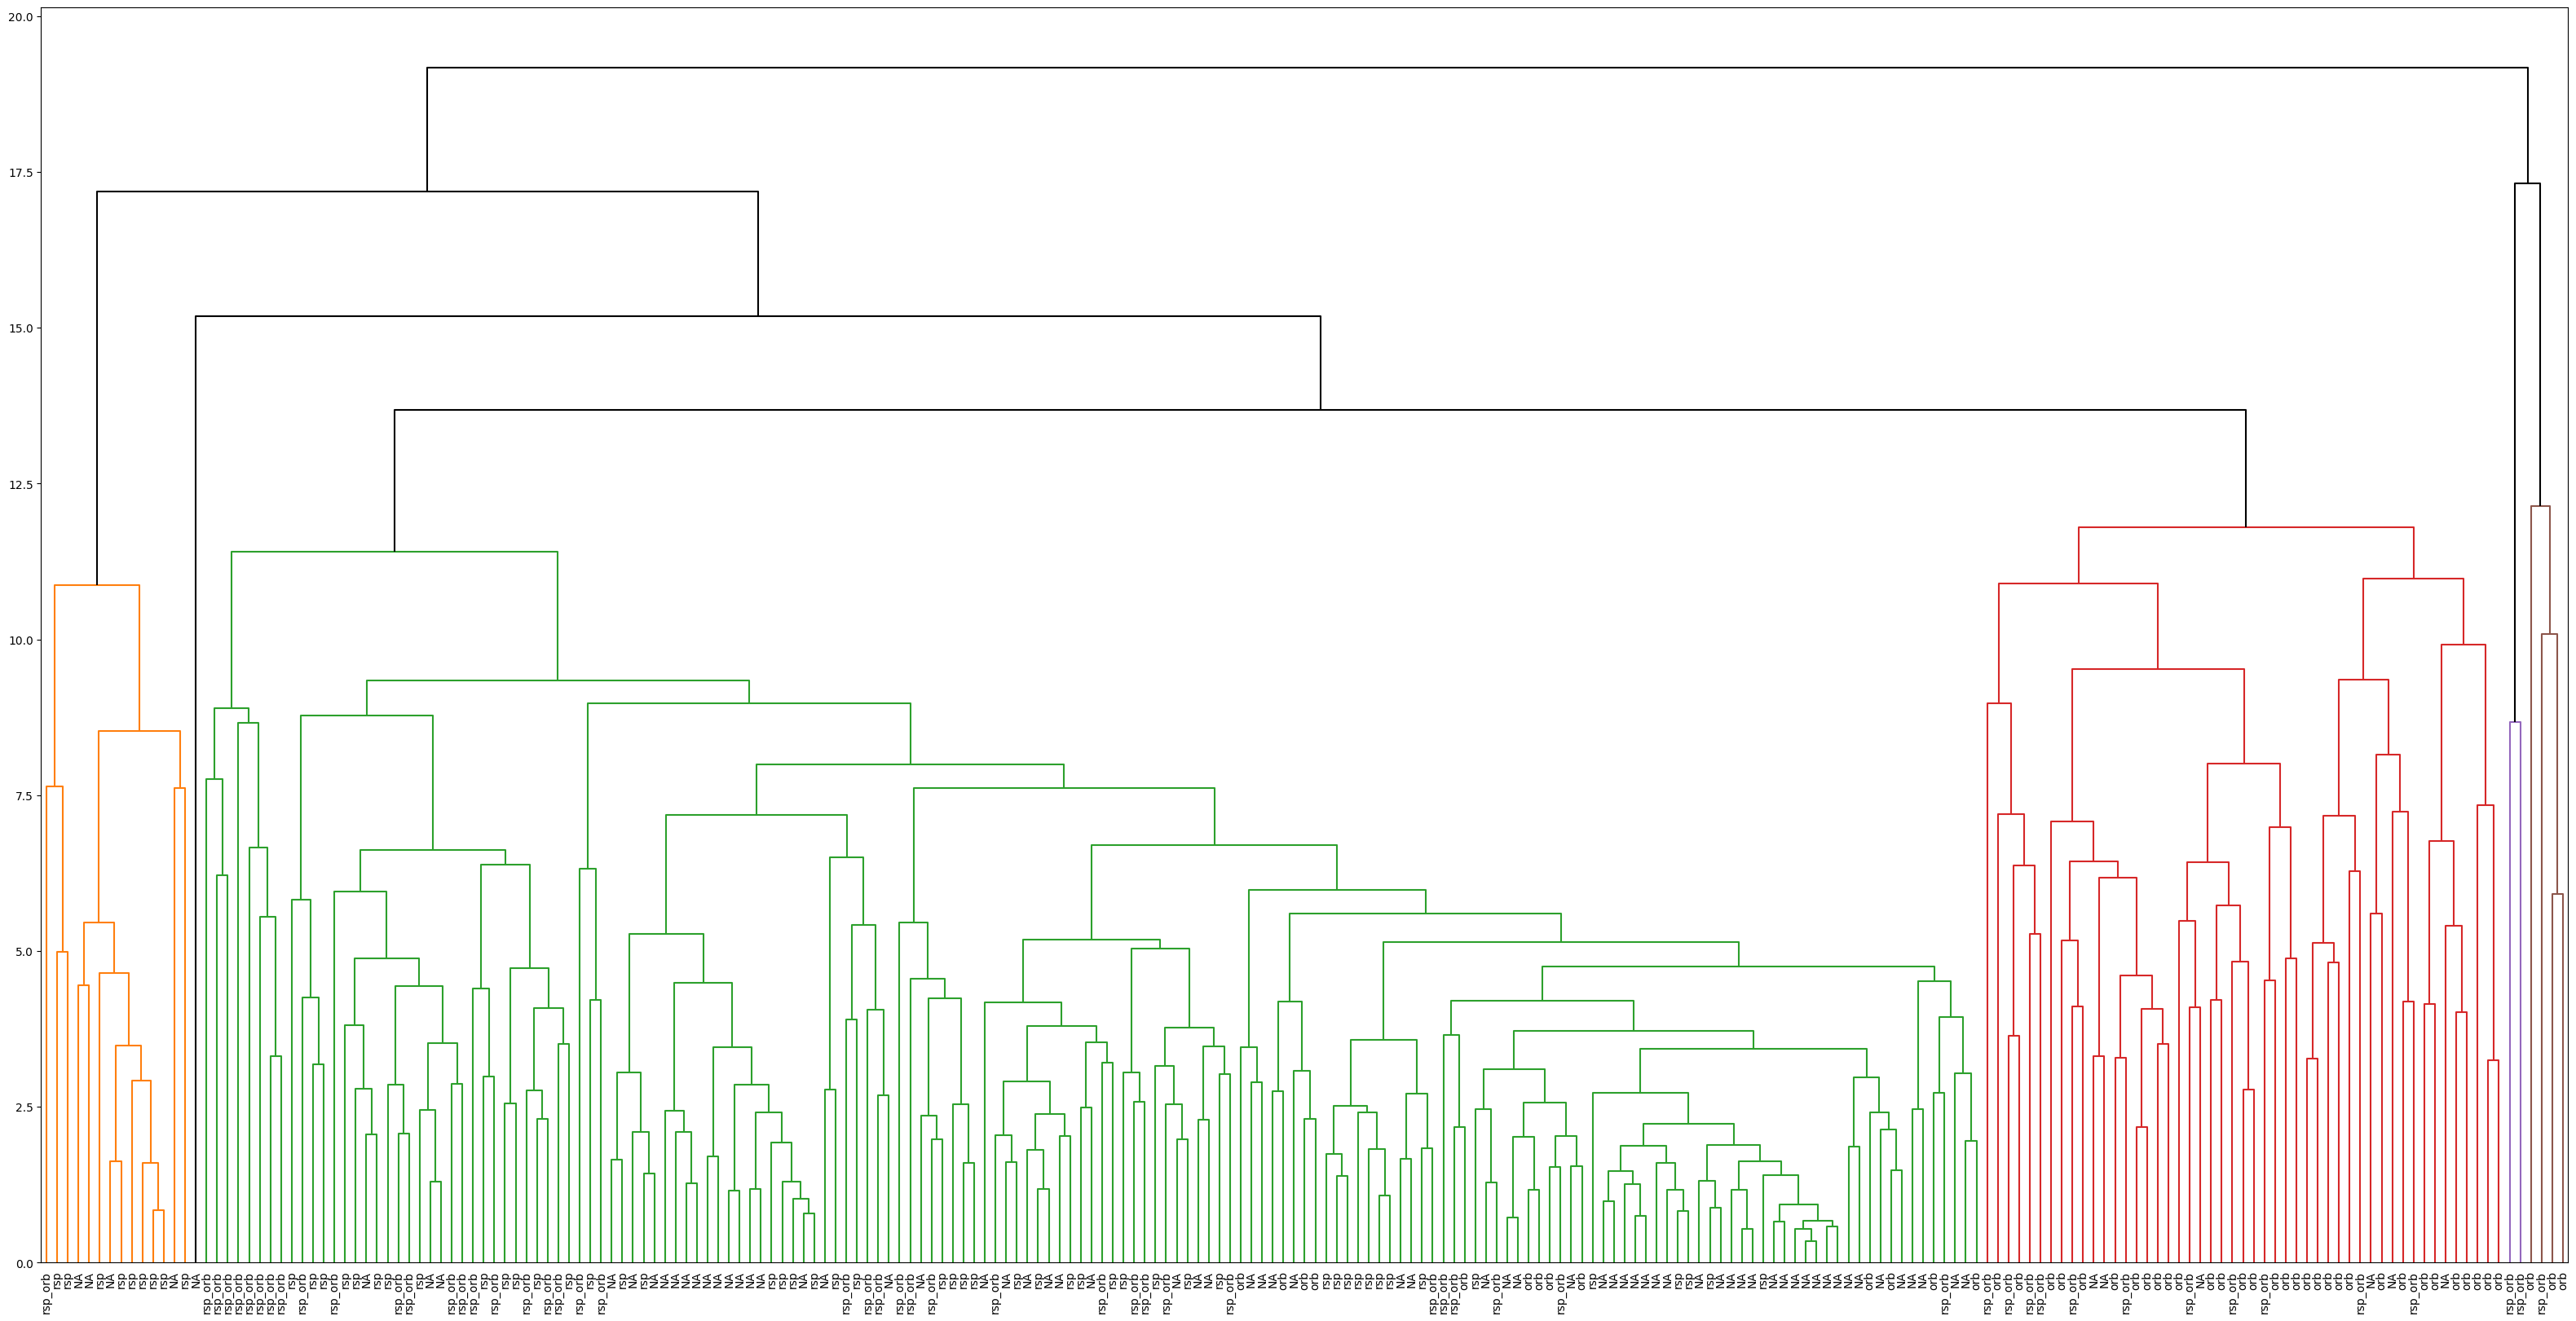

In [20]:
#Run hierarchical clustering
hc_comp = hierarchy.linkage(low_dim_df, method='complete')
# Plot the dendrogram
fig, ax = plt.subplots(1, 1, figsize=(40,20))
hierarchy.dendrogram(hc_comp, ax=ax, labels=np.asarray(labels),
                     color_threshold=13, above_threshold_color='black', leaf_font_size = 10)
plt.show()

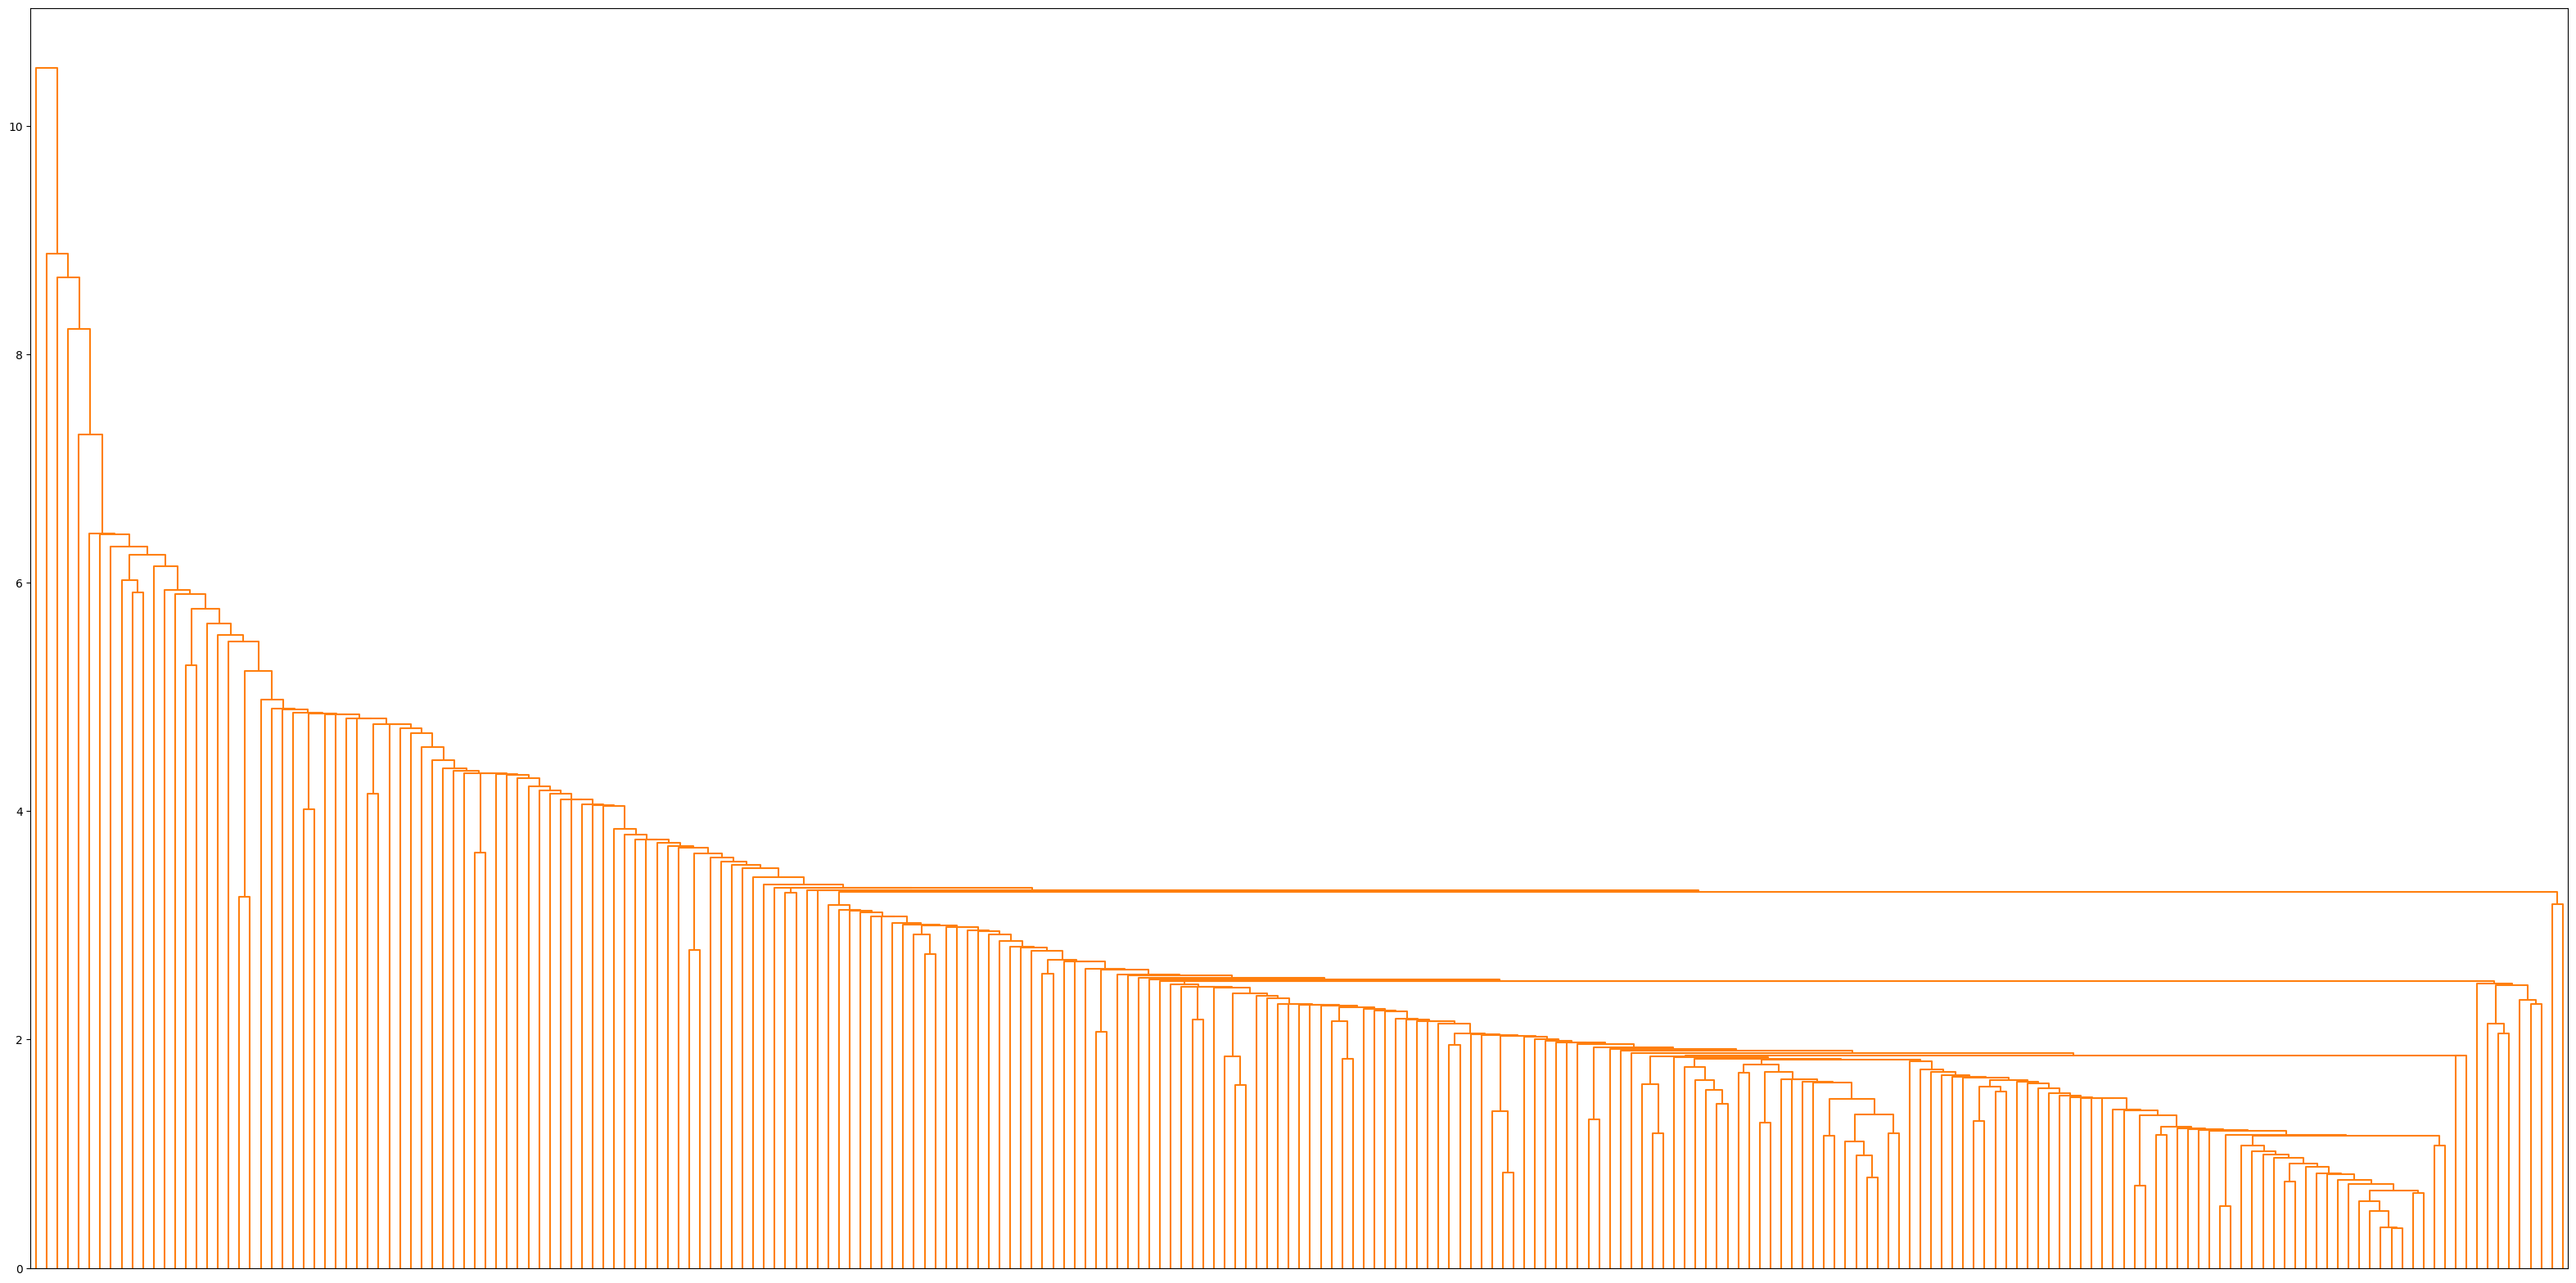

In [21]:
#Run hierarchical clustering
hc_single = hierarchy.linkage(low_dim_df, method='single')
# Plot the dendrogram
fig, ax = plt.subplots(1, 1, figsize=(40,20))
hierarchy.dendrogram(hc_single, ax=ax, no_labels=True,
                     color_threshold=13, above_threshold_color='black', leaf_font_size = 10)
plt.show()

Complete linkage is preferred, more clear separation of clusters and high level merge occurs at larger euclidean distances

In [22]:
cluster_labels = hierarchy.cut_tree(hc_comp, height=13)
cluster_labels_1d = cluster_labels[:, 0]
ct = pd.crosstab(cluster_labels_1d, labels)
ct



proj,NA,orb,rsp,rsp_orb
row_0,,,,
0,6,32,0,11
1,66,13,49,39
2,4,0,9,1
3,0,0,0,2
4,0,3,0,1
5,1,0,0,0


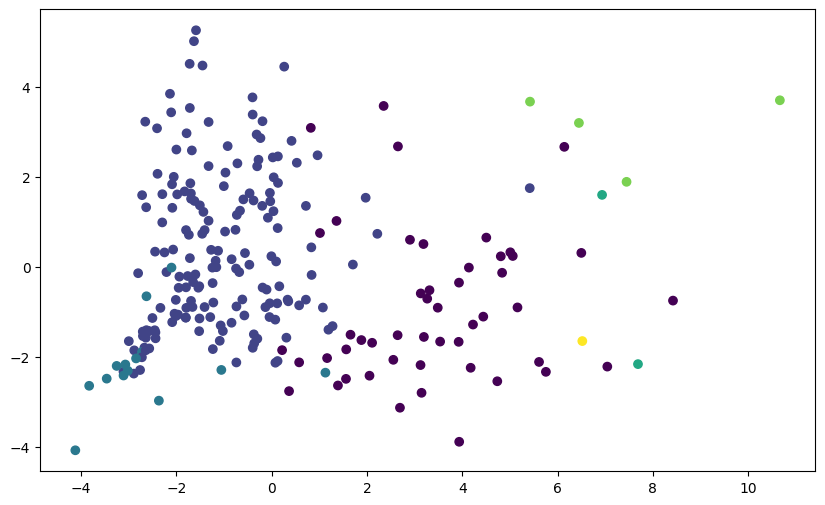

In [23]:
fig, ax = plt.subplots(figsize=(10,6))
ax.scatter(low_dim_df_array[:,0], low_dim_df_array[:,1], c=cluster_labels_1d, cmap="viridis")
plt.show()

In [25]:
import plotly.express as px
import pandas as pd

plot_df = low_dim_df.copy()
plot_df.columns = [f"Dim_{i+1}" for i in range(plot_df.shape[1])]
plot_df["cluster"] = cluster_labels_1d.astype(str)

fig = px.scatter_3d(
    plot_df,
    x="Dim_1",
    y="Dim_2",
    z="Dim_3",
    color="cluster",
    hover_data=plot_df.columns
)

fig.show()